In [70]:
import pandas as pd

df = pd.read_csv(r"C:\practice\Fraud_Detection_Analysis\experiments\Bank_Transaction_Fraud_Detection.csv")

df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [71]:
df.shape

(200000, 24)

In [72]:
drop_cols = [
    "Customer_ID",
    "Customer_Name",
    "Transaction_ID",
    "Customer_Contact",
    "Customer_Email"
]

df = df.drop(columns=drop_cols)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Gender                   200000 non-null  object 
 1   Age                      200000 non-null  int64  
 2   State                    200000 non-null  object 
 3   City                     200000 non-null  object 
 4   Bank_Branch              200000 non-null  object 
 5   Account_Type             200000 non-null  object 
 6   Transaction_Date         200000 non-null  object 
 7   Transaction_Time         200000 non-null  object 
 8   Transaction_Amount       200000 non-null  float64
 9   Merchant_ID              200000 non-null  object 
 10  Transaction_Type         200000 non-null  object 
 11  Merchant_Category        200000 non-null  object 
 12  Account_Balance          200000 non-null  float64
 13  Transaction_Device       200000 non-null  object 
 14  Tran

In [74]:
df["Is_Fraud"].value_counts()

Is_Fraud
0    189912
1     10088
Name: count, dtype: int64

In [75]:
df["Is_Fraud"].value_counts(normalize=True)

Is_Fraud
0    0.94956
1    0.05044
Name: proportion, dtype: float64

In [76]:
fraud_percentage = df["Is_Fraud"].mean() * 100
print(f"Fraud transactions: {fraud_percentage:.2f}%")

Fraud transactions: 5.04%


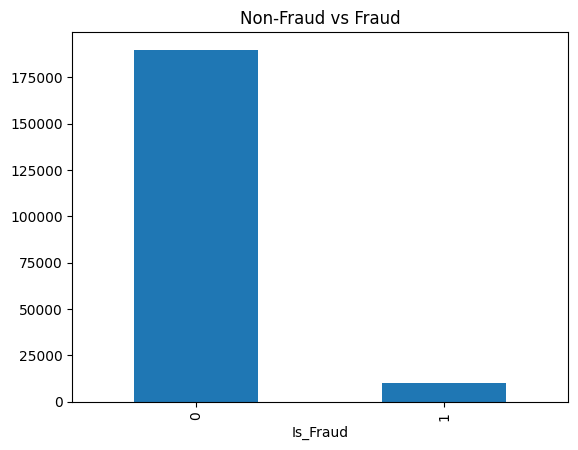

In [77]:
import matplotlib.pyplot as plt

df["Is_Fraud"].value_counts().plot(kind="bar")
plt.title("Non-Fraud vs Fraud")
plt.show()

In [78]:
df.describe()

,Age,Transaction_Amount,Account_Balance,Is_Fraud
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,44.015110,49538.015554,52437.988784,0.050440
std,15.288774,28551.874004,27399.507128,0.218852
min,18.000000,10.290000,5000.820000,0.000000
25%,31.000000,24851.345000,28742.395000,0.000000
50%,44.000000,49502.440000,52372.555000,0.000000
75%,57.000000,74314.625000,76147.670000,0.000000
max,70.000000,98999.980000,99999.950000,1.000000


In [79]:
import pandas as pd

df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

df['Transaction_Time'] = pd.to_datetime(
    df['Transaction_Time'],
    format='%H:%M:%S'
)

df['Transaction_Hour'] = df['Transaction_Time'].dt.hour
df['Transaction_Day'] = df['Transaction_Date'].dt.day
df['Transaction_Month'] = df['Transaction_Date'].dt.month
df['Transaction_Weekday'] = df['Transaction_Date'].dt.dayofweek
df['Is_Weekend'] = (df['Transaction_Weekday'] >= 5).astype(int)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18440\1029415701.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])


In [80]:
df['Amount_Balance_Ratio'] = (
    df['Transaction_Amount'] /
    (df['Account_Balance'] + 1)
)

In [81]:
df['Remaining_Balance'] = (
    df['Account_Balance'] -
    df['Transaction_Amount']
)

In [82]:
import numpy as np

df['Log_Transaction_Amount'] = np.log1p(
    df['Transaction_Amount']
)

In [83]:
merchant_risk = df.groupby('Merchant_Category')['Is_Fraud'].mean()

df['Merchant_Fraud_Rate'] = (
    df['Merchant_Category']
    .map(merchant_risk)
)

In [84]:
city_risk = df.groupby('City')['Is_Fraud'].mean()

df['City_Fraud_Rate'] = (
    df['City']
    .map(city_risk)
)

In [85]:
state_risk = df.groupby('State')['Is_Fraud'].mean()

df['State_Fraud_Rate'] = (
    df['State']
    .map(state_risk)
)

In [86]:
device_risk = (
    df.groupby('Transaction_Device')['Is_Fraud']
    .mean()
)

df['Device_Fraud_Rate'] = (
    df['Transaction_Device']
    .map(device_risk)
)

In [87]:
threshold = df['Transaction_Amount'].quantile(0.95)

df['High_Amount_Flag'] = (
    df['Transaction_Amount'] > threshold
).astype(int)

In [88]:
def transaction_period(hour):
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

df['Transaction_Period'] = (
    df['Transaction_Hour']
    .apply(transaction_period)
)

In [89]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Gender',
    'State',
    'City',
    'Bank_Branch',
    'Account_Type',
    'Merchant_ID',
    'Transaction_Type',
    'Merchant_Category',
    'Transaction_Device',
    'Transaction_Location',
    'Device_Type',
    'Transaction_Currency',
    'Transaction_Period'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
X = df.drop(
    columns=[
        'Is_Fraud',
        'Transaction_Date',
        'Transaction_Time',
        'Transaction_Description'
    ],
    errors='ignore'
)

y = df['Is_Fraud']

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance.head(20))

In [91]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Transaction_Description    0
Transaction_Hour           0
Transaction_Day            0
Transaction_Month          0
Transaction_Weekday        0
Is_Weekend                 0
Amount_Balance_Ratio       0
Remaining_Balance          0
Log_Transaction_Amount     0
Merchant_Fraud_Rate        0
City_Fraud_Rate            0
State_Fraud_Rate           0
Device_Fraud_Rate          0
High_Amount_Flag           0
Transaction_Period         0
dtype: int64


In [92]:
df

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Date,Transaction_Time,Transaction_Amount,Merchant_ID,...,Is_Weekend,Amount_Balance_Ratio,Remaining_Balance,Log_Transaction_Amount,Merchant_Fraud_Rate,City_Fraud_Rate,State_Fraud_Rate,Device_Fraud_Rate,High_Amount_Flag,Transaction_Period
0,1,60,15,127,127,2,2025-01-23,1900-01-01 16:04:07,32415.45,25908,...,0,0.434767,42141.82,10.386421,0.050350,0.048246,0.045340,0.051250,0,0
1,0,51,18,100,100,0,2025-01-11,1900-01-01 17:14:53,43622.60,195310,...,1,0.584568,31000.06,10.683354,0.050350,0.048000,0.050830,0.050712,0,0
2,1,20,4,13,13,2,2025-01-25,1900-01-01 03:09:52,63062.56,118512,...,1,0.943782,3755.43,11.051898,0.051888,0.042142,0.046611,0.048726,0,3
3,0,57,28,22,22,0,2025-01-19,1900-01-01 12:27:02,14000.72,191023,...,1,0.240653,44176.36,9.546935,0.048233,0.050818,0.056155,0.049695,0,0
4,0,43,25,7,7,2,2025-01-30,1900-01-01 18:30:46,18335.16,88278,...,0,1.138154,-2226.60,9.816630,0.048233,0.043515,0.047192,0.054473,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,0,55,7,33,33,0,2025-01-08,1900-01-01 18:42:09,98513.74,89534,...,0,2.628708,-61038.63,11.497961,0.050350,0.050026,0.052074,0.051012,1,1
199996,1,51,19,63,63,0,2025-01-01,1900-01-01 20:51:21,40593.55,6533,...,0,0.765364,12443.65,10.611389,0.051888,0.047883,0.050605,0.048726,0,1
199997,0,41,5,21,21,2,2025-01-28,1900-01-01 10:47:40,61579.70,127455,...,0,0.639946,34645.66,11.028104,0.049852,0.047941,0.049681,0.048726,0,2
199998,0,28,29,103,103,1,2025-01-08,1900-01-01 06:26:41,39488.22,6880,...,0,0.440712,50111.68,10.583783,0.050316,0.055461,0.052923,0.051250,0,2


In [93]:

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (200000, 29)
Target Shape: (200000,)


In [94]:
print("\nFraud Distribution:")
print(y.value_counts())

print("\nFinal Dataset Shape:", df.shape)


Fraud Distribution:
Is_Fraud
0    189912
1     10088
Name: count, dtype: int64

Final Dataset Shape: (200000, 33)


In [101]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [98]:
print(y_train.value_counts())
print(y_test.value_counts())

Is_Fraud
1    152002
0    151857
Name: count, dtype: int64
Is_Fraud
0    38055
1    37910
Name: count, dtype: int64


In [99]:
import dagshub
import mlflow
with mlflow.start_run():
  mlflow.log_param('parameter name', 'value')
  mlflow.log_metric('metric name', 1)

mlflow.set_tracking_uri('https://dagshub.com/Shrutichauha7/Fraud_Detection_Analysis.mlflow')
dagshub.init(repo_owner='Shrutichauha7', repo_name='Fraud_Detection_Analysis', mlflow=True)


mlflow.set_experiment("Logistic Regression Baseline")

Accessing as Shrutichauha7

Initialized MLflow to track repo "Shrutichauha7/Fraud_Detection_Analysis"

Repository Shrutichauha7/Fraud_Detection_Analysis initialized!

<Experiment: artifact_location='mlflow-artifacts:/99a9b21a75f944349c1c5346e91c8d22', creation_time=1779982969733, experiment_id='0', last_update_time=1779982969733, lifecycle_stage='active', name='Logistic Regression Baseline', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [100]:
import mlflow
import logging
import os
import time

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Starting MLflow run...")

with mlflow.start_run():

    start_time = time.time()

    try:
        
        logging.info("Logging Preprocessing Parameters")

        mlflow.log_param("model", "LogisticRegression")
        mlflow.log_param("test_size", 0.2)
        

        logging.info("Training model...")
        model = LogisticRegression(max_iter=1000)
        model.fit(X_resampled, y_resampled)


        logging.info("Making predictions...")
        y_pred = model.predict(X_test)

       
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred)

       
        logging.info("Logging metrics...")

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)

        logging.info("Saving model...")

        mlflow.sklearn.log_model(
            model,"model"
        )


        execution_time = time.time() - start_time

        mlflow.log_metric(
            "execution_time_seconds",
            execution_time
        )

        logging.info(f"Accuracy: {accuracy}")
        logging.info(f"Precision: {precision}")
        logging.info(f"Recall: {recall}")
        logging.info(f"F1 Score: {f1}")
        logging.info(f"ROC-AUC: {auc}")

        print("MLflow Run Completed Successfully!")

    except Exception as e:

        logging.error(f"Error occurred: {e}")

        mlflow.log_param("error", str(e))

        raise

2026-06-06 16:50:40,279 - INFO - Starting MLflow run...
2026-06-06 16:50:40,816 - INFO - Logging Preprocessing Parameters
2026-06-06 16:50:41,606 - INFO - Training model...
c:\Users\Lenovo\anaconda3\envs\vehicle\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026-06-06 16:51:13,428 - INFO - Making predictions...
c:\Users\Lenovo\anaconda3\envs\vehicle\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was 

MLflow Run Completed Successfully!
🏃 View run wistful-colt-163 at: https://dagshub.com/Shrutichauha7/Fraud_Detection_Analysis.mlflow/#/experiments/0/runs/9ef5a79096d945be85055c3a70ac3f04
🧪 View experiment at: https://dagshub.com/Shrutichauha7/Fraud_Detection_Analysis.mlflow/#/experiments/0
